# Criteo Uplift Modelling — Notebook 1: EDA & Experiment Validity

---

## The Business Problem

When a company runs a marketing campaign — sending a promotional email, showing an ad, offering a discount — it wants to know whether the campaign actually *caused* customers to respond, or whether those customers would have bought anyway.

This distinction matters enormously. If you spend budget targeting customers who were going to convert regardless, you've wasted money. If you target customers who actively dislike being contacted, you may actually drive them away. The real commercial goal is to identify the customers for whom the intervention makes a genuine difference — those who will respond *because* of the campaign, not despite it or independently of it.

This is the problem **uplift modelling** is designed to solve. Rather than predicting who is most likely to convert (a standard classification problem), uplift modelling predicts the *incremental effect* of a treatment on each individual — who is more likely to convert *because* they were targeted.

---

## The Dataset

Criteo, a digital advertising company, ran a large-scale randomised controlled experiment across 13 million users and published the results as an open dataset. Each row represents one user. The fields are:

| Field | Description |
|---|---|
| **f0 – f11** | Twelve anonymised numerical features representing user characteristics (e.g. purchase history, browsing behaviour, demographics) |
| **treatment** | Whether the user was assigned to the treatment group (1) or control group (0) — randomly assigned |
| **exposure** | Whether the user actually saw the advertisement (1) or not (0) — being assigned to treatment doesn't guarantee exposure |
| **visit** | Whether the user subsequently visited the advertiser's website — our **primary outcome** |
| **conversion** | Whether the user made a purchase — a secondary outcome, rarer and harder to model reliably |

---

## Our Approach

The analysis proceeds in three notebooks:

- **Notebook 1 (this notebook):** Examine the data, validate the experiment, and understand the structure of the dataset before drawing any conclusions.
- **Notebook 2:** Conduct an A/B test to measure the Average Treatment Effect (ATE) — whether the campaign had a statistically significant impact on visit and conversion rates.
- **Notebook 3:** Build an uplift model to predict the individual-level treatment effect, enabling targeted rather than blanket campaign deployment.

---

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

# Consistent plot styling throughout
style.use('ggplot')
sns.set_style('whitegrid')
sns.set_palette('muted')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

print("Libraries loaded successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Libraries loaded successfully.
pandas 2.2.3 | numpy 2.1.3


---
## 2. Load Data

The dataset is available from the [Criteo AI Lab](https://ailab.criteo.com/ressources/criteo-uplift-modeling-dataset/) and [Kaggle](https://www.kaggle.com/code/hughhuyton/criteo-uplift-modelling).

Download `criteo-uplift-v2.1.csv` and update the path below.

> **Note:** The file is approximately 3.25 GB. Loading it takes around 30–60 seconds depending on your machine.

In [2]:
# Update this path to wherever you have saved the dataset
DATA_PATH = 'data/criteo-uplift-v2.1.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 13,979,592 rows × 16 columns


---
## 3. Dataset Overview

We start with the basics: data types, missing values, and a first look at the scale of the dataset.

In [3]:
# Data types and non-null counts
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


In [4]:
# Check for missing values
missing = df.isnull().sum()
if missing.any():
    print("Missing values per column:")
    print(missing[missing > 0])
else:
    print("No missing values found.")

No missing values found.


In [5]:
# First five rows
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.6164,10.0597,8.9764,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
1,12.6164,10.0597,9.0027,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
2,12.6164,10.0597,8.9648,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
3,12.6164,10.0597,9.0028,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
4,12.6164,10.0597,9.0380,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0


In [6]:
# Summary statistics for all columns
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000,13979592.0000
mean,19.6203,10.0700,8.4466,4.1789,10.3388,4.0285,-4.1554,5.1018,3.9336,16.0276,5.3334,-0.1710,0.8500,0.0029,0.0470,0.0306
std,5.3775,0.1048,0.2993,1.3366,0.3433,0.4311,4.5779,1.2052,0.0567,7.0190,0.1682,0.0228,0.3571,0.0539,0.2116,0.1723
min,12.6164,10.0597,8.2144,-8.3984,10.2805,-9.0119,-31.4298,4.8338,3.6351,13.1901,5.3004,-1.3839,0.0000,0.0000,0.0000,0.0000
25%,12.6164,10.0597,8.2144,4.6799,10.2805,4.1155,-6.6993,4.8338,3.9108,13.1901,5.3004,-0.1687,1.0000,0.0000,0.0000,0.0000
50%,21.9234,10.0597,8.2144,4.6799,10.2805,4.1155,-2.4111,4.8338,3.9719,13.1901,5.3004,-0.1687,1.0000,0.0000,0.0000,0.0000
75%,24.4365,10.0597,8.7233,4.6799,10.2805,4.1155,0.2944,4.8338,3.9719,13.1901,5.3004,-0.1687,1.0000,0.0000,0.0000,0.0000
max,26.7453,16.3442,9.0520,4.6799,21.1235,4.1155,0.2944,11.9984,3.9719,75.2950,6.4739,-0.1687,1.0000,1.0000,1.0000,1.0000


**What to look for here:**
- All 12 feature columns (f0-f11) are continuous floats — no encoding required
- `treatment`, `exposure`, `visit`, and `conversion` are binary (0/1)
- Missing values, if any, would need to be addressed before modelling – confirmed no missing values
- Several features show identical 25th, 50th, and 75th percentile values in the summary statistics above, suggesting heavily quantised distributions – most users share the same value for those features. This will be explored further in the feature distributions section

---
## 4. Outcome & Treatment Distributions

Before checking whether the experiment was valid, we need to understand the shape of the key variables: how the treatment was allocated, and how rare the outcomes are.

In [7]:
# Treatment / control split
treatment_counts = df['treatment'].value_counts()
treatment_pct = df['treatment'].value_counts(normalize=True) * 100

print("Treatment group sizes:")
print(pd.DataFrame({
    'Count': treatment_counts,
    'Percentage': treatment_pct.round(1)
}).rename(index={0: 'Control', 1: 'Treatment'}))

Treatment group sizes:
              Count  Percentage
treatment                      
Treatment  11882655     85.0000
Control     2096937     15.0000


We look at three related but distinct metrics:

**Visit rate** — the proportion of *all users* who visited the advertiser's website. This is the broadest measure of campaign reach and our primary outcome of interest throughout the analysis.

**Purchase rate** — the proportion of *all users* who made a purchase. This is rarer than visits because it requires a user to both arrive at the site *and* complete a transaction. It is the ultimate commercial outcome but a noisier signal due to how infrequently it occurs.

**Conversion rate** — the proportion of *visitors* who then went on to purchase. This is the conventional e-commerce meaning of "conversion rate" and measures site effectiveness rather than campaign effectiveness: once a user arrives, how likely are they to buy? The relationship between the three metrics is straightforward: Purchase rate = Visit rate x Conversion rate.

In this dataset, getting users to the site is the harder problem — visit rates are in the low single digits. Once there, however, a meaningful proportion go on to purchase, suggesting the campaign's primary job is to drive visits rather than to improve on-site conversion.

In [8]:
# Outcome rates overall
outcomes = pd.DataFrame({
    'Metric': ['Visit rate', 'Purchase rate', 'Conversion rate (among visitors)'],
    'Value (%)': [
        round(df['visit'].mean() * 100, 3),
        round(df['conversion'].mean() * 100, 3),
        round(df[df['visit'] == 1]['conversion'].mean() * 100, 3)
    ]
})
print(outcomes.to_string(index=False))

                          Metric  Value (%)
                      Visit rate     4.6990
                   Purchase rate     0.2920
Conversion rate (among visitors)     6.2070


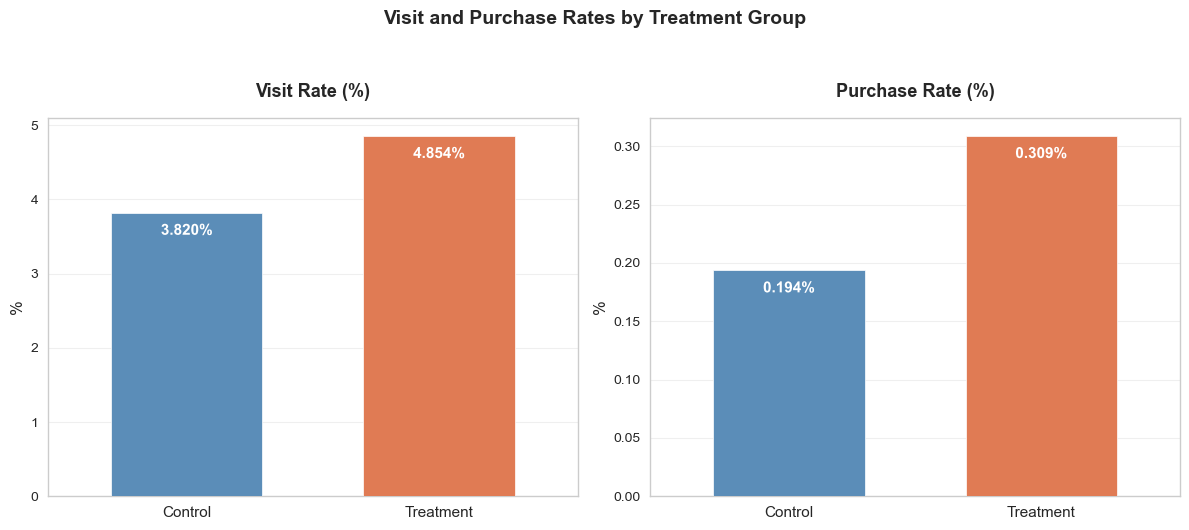

In [9]:
# Visit and purchase rates by treatment group

import matplotlib.patheffects as path_effects

# 1. Setup figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#5B8DB8', '#E07B54'] # Blue and Orange

for ax, col, label in zip(
    axes,
    ['visit', 'conversion'],
    ['Visit Rate (%)', 'Purchase Rate (%)']
):
    # Calculate rates
    rates = df.groupby('treatment')[col].mean() * 100
    
    # Plot bars
    bars = rates.plot(
        kind='bar', ax=ax,
        color=colors,
        width=0.6, edgecolor='white',
        zorder=3
    )
    
    # Clean up grid (Removes those central lines)
    ax.yaxis.grid(True, linestyle='-', alpha=0.3, zorder=0)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    
    # Formatting
    ax.set_title(label, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_xticklabels(['Control', 'Treatment'], rotation=0, fontsize=11)
    ax.set_ylabel('%')

    # --- Internal Colored Labels ---
    for i, p in enumerate(ax.patches):
        # Determine bar color to match text outline
        current_color = colors[i % len(colors)]
        
        ax.annotate(
            f'{p.get_height():.3f}%',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', 
            va='top',               # Aligns the top of the text to the coordinate
            fontsize=11, 
            fontweight='bold',
            color='white',          # White text for contrast inside the bar
            xytext=(0, -8),         # Moves text 8 points DOWN from the top
            textcoords='offset points',
            # Adds a subtle outline of the bar's color for better legibility
            path_effects=[path_effects.withStroke(linewidth=3, foreground=current_color)]
        )

# Main title and Footnote
plt.suptitle('Visit and Purchase Rates by Treatment Group', fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

**Key observations:**
- The dataset is **imbalanced**: 85% of users were in the treatment group and 15% in the control group. This is common in incrementality tests where withholding treatment from a large share of users has commercial costs — but it has implications for modelling and will need to be addressed in Notebook 3.
- Both visit and purchase rates are **very low** (single-digit percentages), which is typical for digital advertising datasets. The vast majority of users do not visit or purchase regardless of treatment.
- Despite these small absolute rates, the *difference* between treatment and control groups is what matters commercially. We will test this formally in Notebook 2.

---
## 5. Exposure Analysis

The dataset contains an `exposure` variable indicating whether a user in the treatment group actually *saw* the advertisement. This is an important distinction: being assigned to the treatment group does not mean the treatment was received.

This matters because including unexposed users in the treatment group dilutes the apparent effect of the campaign. We need to understand the scale of this dilution.

A note on the control group: control group users have `exposure = 0` by definition, but this does not mean we can verify they had zero contact with the advertiser. They were deliberately not *targeted* by the campaign, but may have encountered the advertiser's content through other channels (e.g. organic search, direct navigation, or word of mouth). The experiment makes no attempt to measure this. The assumption, reasonable given the randomisation, is that any such incidental exposure is distributed roughly equally across both groups and does not systematically bias the results. The three groups in the analysis below are therefore more precisely characterised as: users not targeted (control); users targeted but not demonstrably engaged (treated, not exposed); and users targeted and demonstrably engaged (treated, exposed).

In [10]:
# Exposure rate within treatment group
exposure_in_treatment = df[df['treatment'] == 1]['exposure'].value_counts(normalize=True) * 100
print("Exposure rates among treated users:")
print(pd.DataFrame({
    'Percentage': exposure_in_treatment.round(2)
}).rename(index={0: 'Not exposed', 1: 'Exposed'}))

Exposure rates among treated users:
             Percentage
exposure               
Not exposed     96.4000
Exposed          3.6000


In [11]:
# Outcome rates: exposed vs not exposed (within treatment group)
treated = df[df['treatment'] == 1]
exp_outcomes = treated.groupby('exposure')[['visit', 'conversion']].mean() * 100
exp_outcomes.index = ['Not Exposed', 'Exposed']
exp_outcomes.columns = ['Visit Rate (%)', 'Conversion Rate (%)']
print("Outcomes within treatment group, by exposure:")
print(exp_outcomes.round(3))

Outcomes within treatment group, by exposure:
             Visit Rate (%)  Conversion Rate (%)
Not Exposed          3.4860               0.1190
Exposed             41.4540               5.3780


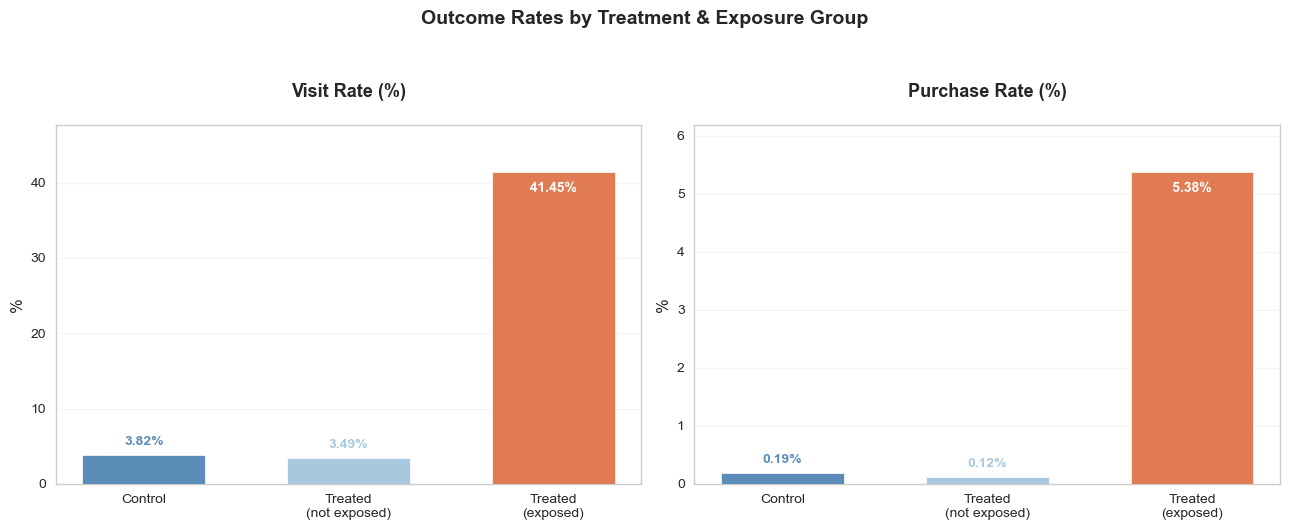

In [14]:
# Define the groups
groups = {
    'Control': df[df['treatment'] == 0],
    'Treated\n(not exposed)': df[(df['treatment'] == 1) & (df['exposure'] == 0)],
    'Treated\n(exposed)': df[(df['treatment'] == 1) & (df['exposure'] == 1)],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#5B8DB8', '#A8C8E0', '#E07B54'] # Added a lighter blue for the middle bar

for ax, outcome, label in zip(axes, ['visit', 'conversion'], ['Visit Rate (%)', 'Purchase Rate (%)']):
    rates = [grp[outcome].mean() * 100 for grp in groups.values()]
    bars = ax.bar(groups.keys(), rates, color=colors, width=0.6, edgecolor='white', zorder=3)
    
    ax.yaxis.grid(True, linestyle='-', alpha=0.2, zorder=0)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    
    # Standard formatting
    ax.set_title(label, fontsize=13, fontweight='bold', pad=20)
    ax.set_ylabel('%')
    
    # Get current y-axis limit to determine "short" vs "tall" bars
    y_max = max(rates) if rates else 1

    for i, bar in enumerate(bars):
        height = bar.get_height()
        current_color = colors[i]
        
        # Logic: If bar is shorter than 15% of the max height, put label ABOVE
        if height < (y_max * 0.15):
            ax.annotate(
                f'{height:.2f}%',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold',
                color=current_color,    # Use bar color for text when outside
                xytext=(0, 5),          # Offset up
                textcoords='offset points'
            )
        else:
            # Keep inside for tall bars
            ax.annotate(
                f'{height:.2f}%',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='top',
                fontsize=10, fontweight='bold',
                color='white',          # White text when inside
                xytext=(0, -8),         # Offset down
                textcoords='offset points',
                path_effects=[path_effects.withStroke(linewidth=3, foreground=current_color)]
            )

    # Add a bit of padding to the top so labels don't hit the ceiling
    ax.set_ylim(0, y_max * 1.15)

plt.suptitle('Outcome Rates by Treatment & Exposure Group', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Key observations:**
- Only approximately **3.6% of treated users** were actually exposed to the advertisement — roughly 1 in 28.
- The orange bar represents only the 3.6% of treated users who were actually exposed; the light blue bar represents the remaining 96.4%.
- Among exposed users, visit and conversion rates are dramatically higher than either the control group or unexposed treated users. This suggests the campaign is effective *when it reaches people*, but has very poor reach.
- Unexposed treated users actually perform *worse* than the control group on both outcomes. One possible explanation: users who don't engage with any advertising may be systematically less likely to convert. This is a confounding factor worth noting.
- This distinction between `treatment` and `exposure` will be explored further in Notebook 3, where we build separate uplift models for each.

---
## 6. Feature Distributions

The 12 anonymised features (f0–f11) are the inputs to our uplift model. Before modelling, we examine their distributions to understand scale, spread, and any potential outliers.

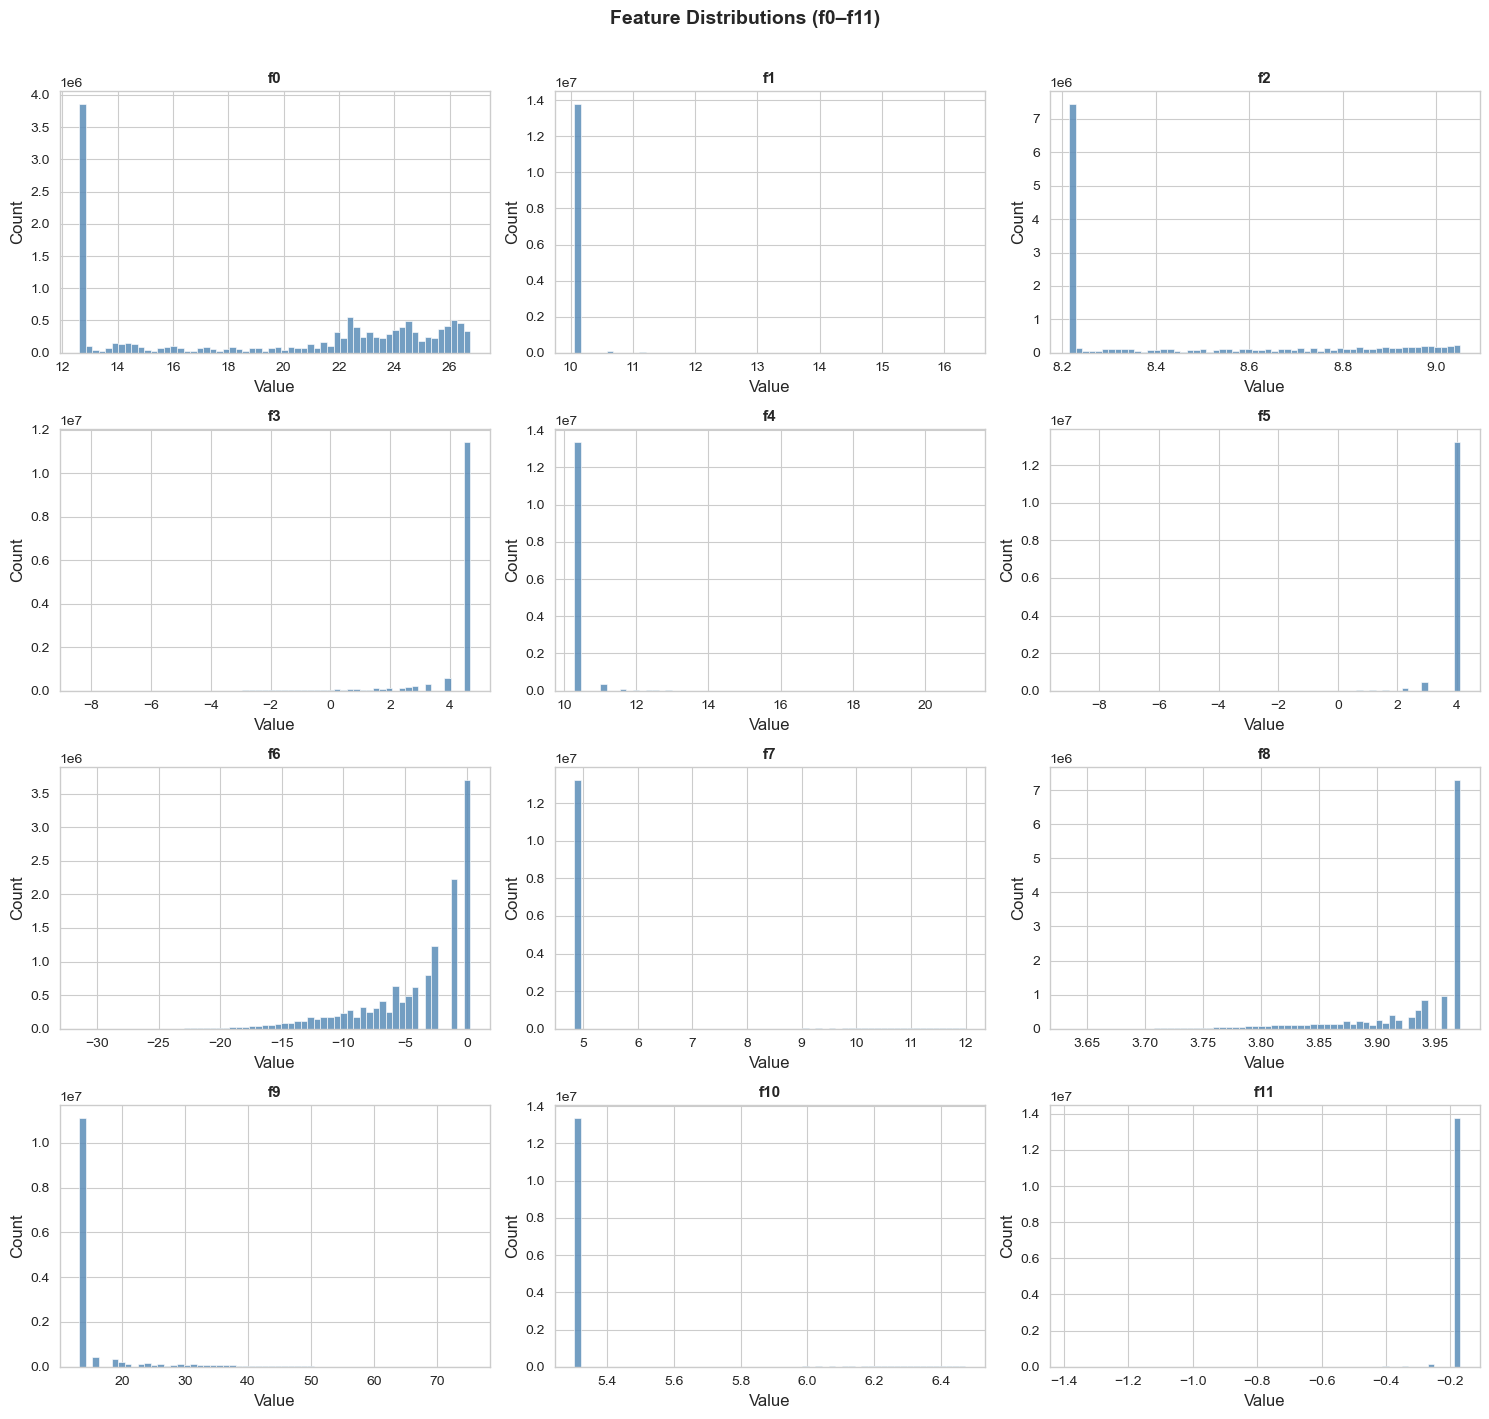

In [15]:
feature_cols = [f'f{i}' for i in range(12)]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=60, color='#5B8DB8', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions (f0–f11)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**What to look for:**
- Heavy skew or extreme outliers in any feature may affect model performance and could warrant transformation
- Features on very different scales will need standardisation before any distance-based modelling (though tree-based models like XGBoost are scale-invariant)
- Several features (f1, f2, f3, f4, f5, f7, f8, f9, f10, f11) show identical values at the 25th, 50th, and 75th percentiles, meaning at least 75% of users share the same value for those features. This is unusual for continuous variables and likely reflects heavy quantisation or discretisation applied as part of the anonymisation process — visible as sharp spikes in the histograms above. This does not prevent the model from using these features, but is worth bearing in mind when interpreting their importance
- For f3, f4, f5, f7, and f8, the pattern is even more extreme — the 75th percentile equals the maximum value exactly, meaning the vast majority of users share a single value while a small minority have substantially lower values. These features are effectively binary in practice, distinguishing a small outlier population from the rest

---
## 7. Feature Correlation

A correlation heatmap shows whether any features are strongly related to each other. High multicollinearity between features doesn't affect tree-based models significantly, but is worth understanding.

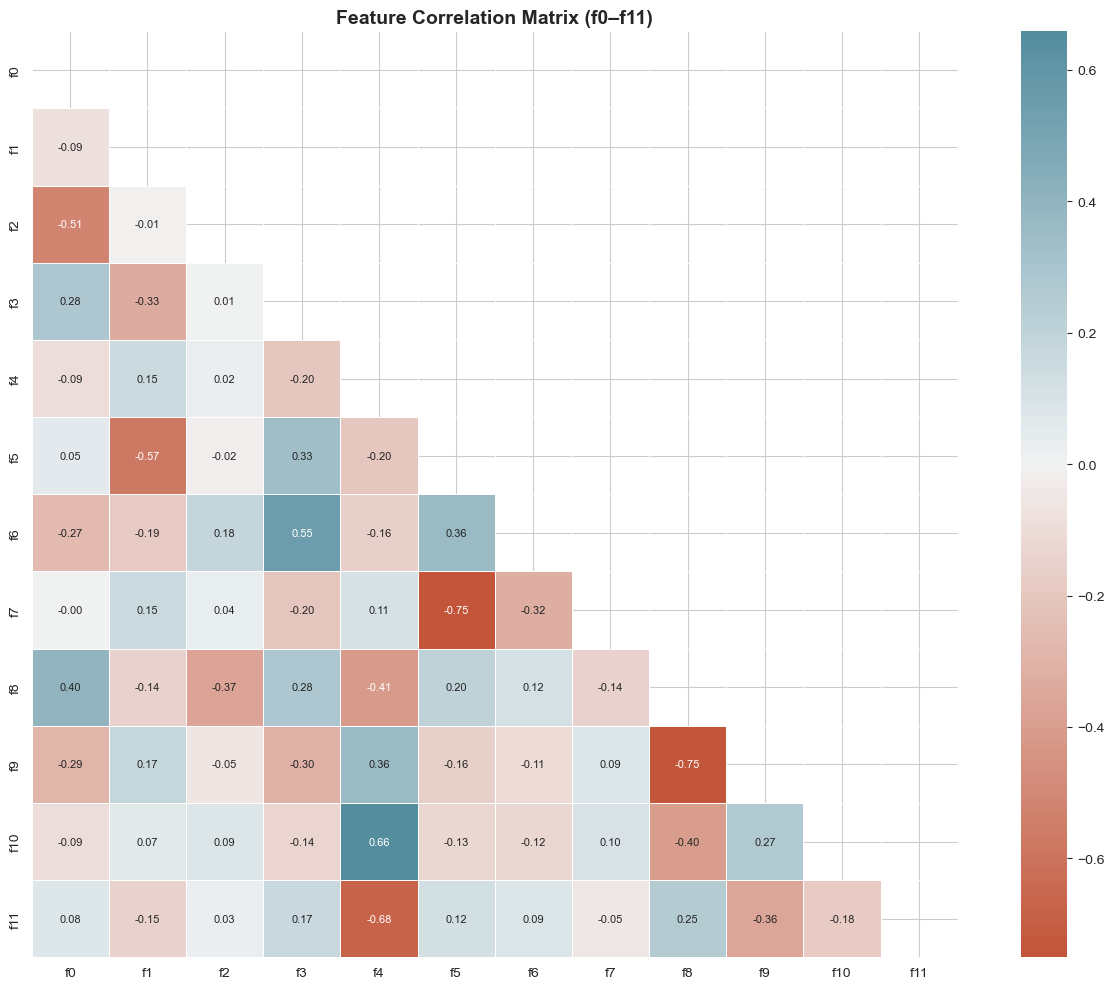

In [16]:
corr = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True,
    fmt='.2f',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix (f0–f11)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Randomisation Check

This is the most important step in validating an experiment. If the randomisation worked correctly, the treatment and control groups should be statistically indistinguishable across all 12 features — any differences in outcomes can then be attributed to the treatment rather than pre-existing differences between groups.

We use **Standardised Mean Difference (SMD)** to assess balance. SMD measures the difference in feature means between groups, scaled by the pooled standard deviation:

$$SMD = \frac{\bar{X}_{treatment} - \bar{X}_{control}}{\sqrt{\frac{s^2_{treatment} + s^2_{control}}{2}}}$$

A commonly used threshold is **|SMD| < 0.1**, which indicates good balance. Values above this suggest the groups may differ on that feature in ways that could confound the analysis.

In [17]:
def standardised_mean_difference(df, features, treatment_col='treatment'):
    """
    Calculate Standardised Mean Difference (SMD) for each feature
    between treatment and control groups.
    |SMD| < 0.1 is conventionally considered well-balanced.
    """
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    results = []
    for col in features:
        mean_t = treated[col].mean()
        mean_c = control[col].mean()
        var_t = treated[col].var()
        var_c = control[col].var()
        pooled_sd = np.sqrt((var_t + var_c) / 2)
        smd = (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else 0
        results.append({
            'Feature': col,
            'Mean (Treatment)': round(mean_t, 4),
            'Mean (Control)': round(mean_c, 4),
            'SMD': round(smd, 4),
            'Balanced (|SMD| < 0.1)': abs(smd) < 0.1
        })

    return pd.DataFrame(results).set_index('Feature')

smd_df = standardised_mean_difference(df, feature_cols)
print(smd_df.to_string())

         Mean (Treatment)  Mean (Control)     SMD  Balanced (|SMD| < 0.1)
Feature                                                                  
f0                19.6148         19.6517 -0.0069                    True
f1                10.0703         10.0679  0.0240                    True
f2                 8.4463          8.4482 -0.0062                    True
f3                 4.1694          4.2328 -0.0488                    True
f4                10.3392         10.3365  0.0080                    True
f5                 4.0266          4.0393 -0.0306                    True
f6                -4.1828         -3.9999 -0.0404                    True
f7                 5.1056          5.0803  0.0213                    True
f8                 3.9334          3.9347 -0.0224                    True
f9                16.0526         15.8863  0.0240                    True
f10                5.3337          5.3319  0.0106                    True
f11               -0.1710         -0.1

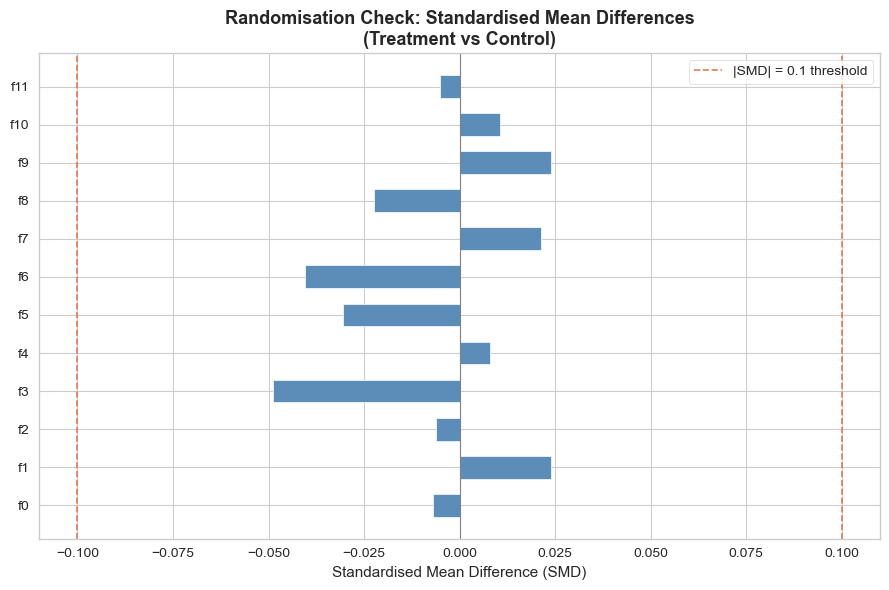

In [18]:
# Visualise SMD — Love plot
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#E07B54' if abs(v) >= 0.1 else '#5B8DB8' for v in smd_df['SMD']]

ax.barh(smd_df.index, smd_df['SMD'], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0.1, color='#E07B54', linestyle='--', linewidth=1.2, label='|SMD| = 0.1 threshold')
ax.axvline(x=-0.1, color='#E07B54', linestyle='--', linewidth=1.2)
ax.axvline(x=0, color='grey', linestyle='-', linewidth=0.8)

ax.set_xlabel('Standardised Mean Difference (SMD)', fontsize=11)
ax.set_title('Randomisation Check: Standardised Mean Differences\n(Treatment vs Control)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Interpreting the results:**
- Features where |SMD| is well below 0.1 indicate that randomisation was successful — treatment and control groups are comparable on those dimensions
- Any features exceeding the 0.1 threshold would be a concern worth flagging. In practice, with 13 million users and true random assignment, we would expect all features to be well balanced
- This check gives us confidence that differences in outcomes between groups can be attributed to the treatment rather than pre-existing differences in the user populations

---
## 9. Summary & Implications for Analysis

This notebook has established the following:

**Dataset structure**
- 13 million users, 12 anonymised continuous features, two binary outcome variables (visit and conversion), plus two binary experimental variables (treatment and exposure)
- All features are complete — no missing values

**Treatment allocation**
- ~85% treatment / ~15% control split — imbalanced, which will require resampling before modelling
- Both outcome variables are rare events — visit rates in the low single digits, conversion rates below 1%

**Exposure**
- Only ~3.6% of treated users were actually exposed to the advertisement
- Exposed users show dramatically higher visit and conversion rates than unexposed treated users or control users
- This distinction between *assignment to treatment* and *actual exposure* is analytically important and will be explored in Notebook 3

**Randomisation validity**
- Standardised Mean Differences across all 12 features are well within the accepted threshold of |SMD| < 0.1
- The randomisation was successful — we can proceed with confidence that outcome differences between groups reflect the effect of the treatment

---

**Proceed to Notebook 2: A/B Test Analysis →**